# 제조공정 품질 등급 예측 — 베이스라인 모델 비교 및 앙상블

**목적.** `전처리.ipynb`에서 만든 `A_31_preprocessed.csv`, `TO_31_preprocessed.csv`를 입력으로, CatBoost·XGBoost·LightGBM 세 가지 트리/부스팅 계열 모델의 베이스라인 성능을 같은 조건(같은 폴드, 같은 타깃 설계, 같은 평가지표)에서 비교하고, 이 중 2개·3개 모델을 묶은 앙상블이 단일 모델보다 나은지 확인한다.

**타깃 설계(전처리.ipynb STEP9 재사용).** `Y_Quality`(연속값)를 회귀로 예측한 뒤, 고정 경계값(0.525 / 0.535)으로 잘라 `Y_Class`(0/1/2) 등급으로 바꾼다. 평가지표는 등급별 불균형을 고려한 **Macro-F1**이다.

**구성.**
0. 환경 및 시각화 설정
1. 데이터 로드 및 타깃/검증 설계
2. 공통 평가 프레임 (교차검증 → 등급 변환 → Macro-F1)
3. 베이스라인 모델 정의 (CatBoost / XGBoost / LightGBM)
4. A_31 베이스라인 비교
5. TO_31 베이스라인 비교
6. 앙상블(2모델 / 3모델) 비교
7. 종합 정리 및 한계

## 0. 환경 및 시각화 설정

`제조공정_품질데이터_EDA_확장(상훈).ipynb`와 동일한 폰트·색상 팔레트를 그대로 사용해 프로젝트 전체의 그림 스타일을 통일한다.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display, Markdown

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 한글 폰트 설정 — OS(Windows/macOS/Linux)에 관계없이 사용 가능한 한글 폰트를 자동 선택
import glob

_FONT_FILES = [
    "C:/Windows/Fonts/malgun.ttf", "C:/Windows/Fonts/malgunbd.ttf",   # Windows 맑은 고딕
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",                     # macOS
    "/Library/Fonts/AppleGothic.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",         # Linux (Noto)
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",                # Linux (나눔)
]
for _pat in _FONT_FILES:
    for _f in glob.glob(_pat):
        try:
            font_manager.fontManager.addfont(_f)
        except Exception:
            pass

_available = {f.name for f in font_manager.fontManager.ttflist}
# 1순위: 정확한 폰트명
_PREFER = ["Malgun Gothic", "AppleSDGothic Neo", "AppleGothic", "NanumGothic",
           "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP"]
_KFONT = next((c for c in _PREFER if c in _available), None)
# 2순위: 한글 지원 폰트명 부분일치 (설치 폰트명이 조금 달라도 탐지)
if _KFONT is None:
    _KEYS = ("Malgun", "Nanum", "Noto Sans CJK", "Noto Serif CJK", "AppleGothic", "AppleSDGothic", "Noto Sans KR")
    _KFONT = next((f.name for f in font_manager.fontManager.ttflist
                   if any(k in f.name for k in _KEYS)), "DejaVu Sans")

mpl.rcParams["font.family"] = _KFONT
mpl.rcParams["axes.unicode_minus"] = False   # 축의 마이너스 부호 깨짐 방지
print("한글 폰트:", _KFONT)

sns.set_theme(style="whitegrid", font=_KFONT)
mpl.rcParams.update({
    "figure.figsize": (9, 6), "figure.dpi": 110,
    "axes.titlesize": 16, "axes.titleweight": "bold",
    "axes.labelsize": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.grid": True, "grid.alpha": .35,
})

PAL3   = sns.color_palette("crest", 3)
ACCENT = "#2a6f7f"
GREY   = "#9aa7b1"

RANDOM_STATE = 42
N_SPLITS = 5
LOW, HIGH = 0.525, 0.535   # 전처리.ipynb STEP9과 동일한 고정 경계값
print("setup done")


한글 폰트: Noto Sans CJK JP
setup done


## 1. 데이터 로드 및 타깃·검증 설계

두 제품 블록(A_31, TO_31)은 피처 구성과 등급 분포가 서로 달라 항상 따로 다룬다. 메타 컬럼(`Y_Quality`, `Y_Class`, `PRODUCT_ID`, `PRODUCT_CODE`, `TIMESTAMP`)을 분리하고, 불리언으로 저장된 라인 원-핫 컬럼은 정수로 바꿔 세 라이브러리 모두에서 안전하게 쓰도록 한다.

In [2]:
META_COLS = ['Y_Quality', 'Y_Class', 'PRODUCT_ID', 'PRODUCT_CODE', 'TIMESTAMP']


def load_product(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=['Y_Quality', 'Y_Class']).reset_index(drop=True)   # 라벨 없는 행 방어
    y_quality = df['Y_Quality'].copy()
    y_class = df['Y_Class'].astype(int).copy()
    X = df.drop(columns=[c for c in META_COLS if c in df.columns])
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    return X, y_quality, y_class


X_A, yq_A, yc_A = load_product('A_31_preprocessed.csv')
X_TO, yq_TO, yc_TO = load_product('TO_31_preprocessed.csv')

print('A_31  :', X_A.shape, ' 등급분포', yc_A.value_counts().sort_index().to_dict())
print('TO_31 :', X_TO.shape, ' 등급분포', yc_TO.value_counts().sort_index().to_dict())


A_31  : (316, 572)  등급분포 {0: 76, 1: 150, 2: 90}
TO_31 : (592, 339)  등급분포 {0: 48, 1: 490, 2: 54}


In [3]:
def quality_to_class(y_quality, low=LOW, high=HIGH):
    """Y_Quality 값을 고정 경계값으로 잘라 0/1/2 등급으로 바꾼다 (전처리.ipynb STEP9와 동일한 규칙)."""
    bins = [-np.inf, low, high, np.inf]
    return pd.cut(pd.Series(y_quality), bins=bins, labels=[0, 1, 2]).astype(int).values


def compute_class_weight_map(y_class):
    counts = pd.Series(y_class).value_counts()
    n_classes = len(counts)
    total = len(y_class)
    return {c: total / (n_classes * n) for c, n in counts.items()}


def make_stratified_folds(y_class, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return list(skf.split(np.zeros(len(y_class)), y_class))


folds_A = make_stratified_folds(yc_A)
folds_TO = make_stratified_folds(yc_TO)
weight_map_A = compute_class_weight_map(yc_A)
weight_map_TO = compute_class_weight_map(yc_TO)

print('A_31 클래스 가중치 :', weight_map_A)
print('TO_31 클래스 가중치 :', weight_map_TO)


A_31 클래스 가중치 : {1: 0.7022222222222222, 2: 1.1703703703703703, 0: 1.3859649122807018}
TO_31 클래스 가중치 : {1: 0.40272108843537413, 2: 3.654320987654321, 0: 4.111111111111111}


## 2. 공통 평가 프레임

모든 모델을 같은 방식으로 평가하기 위한 함수다. 폴드마다 (1) 훈련 구간에서 클래스 가중치를 반영해 회귀 모델을 학습하고, (2) 검증 구간의 `Y_Quality`를 예측하고, (3) 고정 경계값으로 등급으로 바꾼 뒤, (4) 실제 등급과 비교해 Macro-F1을 계산한다. 모든 검증 구간의 예측(OOF, out-of-fold)을 모아두면 전체 데이터에 대한 한 번의 Macro-F1(OOF F1)도 계산할 수 있고, 이 OOF 예측은 뒤에서 앙상블에도 그대로 재사용한다.

또한 이 절에서 **해석 자동 생성 함수**(`insight_baseline`, `insight_ensemble`)를 정의한다. 각 차트 아래 '해석 (자동 생성)'은 실제 실행 결과값에서 만들어지므로, 라이브러리 버전이 달라 수치가 바뀌어도 차트와 해석이 항상 같은 결과를 가리킨다.

In [4]:
def run_cv_regression(model_builder, X, y_quality, y_class, weight_map, folds):
    n = len(X)
    oof_pred_quality = np.full(n, np.nan)
    fold_f1 = []

    for tr_idx, va_idx in folds:
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y_quality.iloc[tr_idx]
        w_tr = pd.Series(y_class).iloc[tr_idx].map(weight_map).values

        model = model_builder()
        model.fit(X_tr, y_tr, sample_weight=w_tr)
        pred = model.predict(X_va)
        oof_pred_quality[va_idx] = pred

        pred_class = quality_to_class(pred)
        true_class = np.asarray(y_class)[va_idx]
        fold_f1.append(f1_score(true_class, pred_class, average='macro', labels=[0, 1, 2], zero_division=0))

    oof_class = quality_to_class(oof_pred_quality)
    oof_f1 = f1_score(y_class, oof_class, average='macro', labels=[0, 1, 2], zero_division=0)

    return {
        'fold_f1': np.array(fold_f1),
        'oof_f1': oof_f1,
        'oof_pred_quality': oof_pred_quality,
        'oof_pred_class': oof_class,
    }


# --- 해석 자동 생성 (차트 수치와 항상 일치) ---
def insight_baseline(product, summary, results, note=""):
    s = summary.sort_values("oof_f1", ascending=False)
    names = s.index.tolist()
    top, last = names[0], names[-1]
    f_top, f_second, f_last = s["oof_f1"].iloc[0], s["oof_f1"].iloc[1], s["oof_f1"].iloc[-1]
    std_lo, std_hi = s["fold_std"].min(), s["fold_std"].max()
    allf = np.concatenate([results[m]["fold_f1"] for m in names])
    rank = " > ".join(f"{m}({s.loc[m, 'oof_f1']:.3f})" for m in names)
    gap12, gap_tl = f_top - f_second, f_top - f_last
    if gap_tl <= std_hi:
        sep = (f"최상위·최하위 차이({gap_tl:.3f})도 폴드 표준편차(약 {std_lo:.2f}~{std_hi:.2f}) 범위 안이라 "
               f"뚜렷한 우열로 보기 어렵고, 세 모델을 사실상 비슷한 수준으로 본다.")
    else:
        sep = (f"1·2위 차이({gap12:.3f})는 작지만 최상위 {top}와 최하위 {last}의 차이({gap_tl:.3f})는 "
               f"폴드 표준편차(약 {std_lo:.2f}~{std_hi:.2f})보다 커 어느 정도 근거 있는 차이로 볼 수 있다.")
    txt = (f"**해석 (자동 생성).** {product} 베이스라인 OOF Macro-F1은 {rank} 순이다. {sep} "
           f"표본이 적어 폴드별 F1이 {allf.min():.2f}~{allf.max():.2f}까지 변동한다.")
    return Markdown(txt + (" " + note if note else ""))


def insight_ensemble(product, table, summary, note=""):
    t = table.sort_values("oof_f1", ascending=False)
    short = lambda name: name.split("(")[0].strip()
    rank = " > ".join(f"{short(i)}({t.loc[i, 'oof_f1']:.3f})" for i in t.index)
    best_single = summary.sort_values("oof_f1", ascending=False).index[0]
    bs_val = summary.loc[best_single, "oof_f1"]
    ens_rows = [i for i in t.index if "앙상블" in i]
    ens_best = max(ens_rows, key=lambda r: t.loc[r, "oof_f1"])
    eb_val = t.loc[ens_best, "oof_f1"]
    delta = eb_val - bs_val
    if delta > 0.003:
        verdict = f"최고 앙상블({short(ens_best)} {eb_val:.3f})이 최고 단일 모델({best_single} {bs_val:.3f})보다 {delta:+.3f} 높아 앙상블이 도움이 된다."
    elif delta < -0.003:
        verdict = f"최고 앙상블({eb_val:.3f})이 최고 단일 모델({best_single} {bs_val:.3f})보다 낮아 이 제품에서는 단순 평균 앙상블 이득이 없다."
    else:
        verdict = f"최고 앙상블({eb_val:.3f})과 최고 단일 모델({best_single} {bs_val:.3f})이 사실상 같아 앙상블의 추가 이득은 미미하다."
    txt = f"**해석 (자동 생성).** {product} 순위: {rank}. {verdict}"
    return Markdown(txt + (" " + note if note else ""))

## 3. 베이스라인 모델 정의

세 모델 모두 결측치를 직접 다룰 수 있어 별도 대치 없이 그대로 입력한다. 표본 수가 적고(A_31 316행, TO_31 592행) 피처는 훨씬 많은 구조(p ≫ n)라, 트리 깊이와 학습률을 낮춰 과적합을 억제하는 쪽으로 하이퍼파라미터를 골랐다. 튜닝 전 베이스라인이므로 모델별로 딱 하나의 설정만 사용한다.

In [5]:
def build_catboost():
    return CatBoostRegressor(
        iterations=300, depth=4, learning_rate=0.05,
        l2_leaf_reg=6, random_seed=RANDOM_STATE, verbose=False,
    )


def build_xgboost():
    return XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
        tree_method='hist', random_state=RANDOM_STATE, verbosity=0,
    )


def build_lightgbm():
    return LGBMRegressor(
        n_estimators=300, max_depth=4, num_leaves=15, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
        random_state=RANDOM_STATE, verbose=-1,
    )


MODEL_BUILDERS = {
    'CatBoost': build_catboost,
    'XGBoost': build_xgboost,
    'LightGBM': build_lightgbm,
}


## 4. A_31 베이스라인 비교

In [6]:
results_A = {}
for name, builder in MODEL_BUILDERS.items():
    results_A[name] = run_cv_regression(builder, X_A, yq_A, yc_A, weight_map_A, folds_A)
    r = results_A[name]
    print(f"[A_31] {name:9s}  OOF Macro-F1 = {r['oof_f1']:.3f}  (폴드별 {np.round(r['fold_f1'], 3).tolist()})")


[A_31] CatBoost   OOF Macro-F1 = 0.693  (폴드별 [0.68, 0.595, 0.752, 0.71, 0.72])


[A_31] XGBoost    OOF Macro-F1 = 0.703  (폴드별 [0.779, 0.605, 0.728, 0.729, 0.672])


[A_31] LightGBM   OOF Macro-F1 = 0.676  (폴드별 [0.663, 0.645, 0.693, 0.623, 0.755])


In [7]:
summary_A = pd.DataFrame({
    name: {'oof_f1': r['oof_f1'], 'fold_mean': r['fold_f1'].mean(), 'fold_std': r['fold_f1'].std()}
    for name, r in results_A.items()
}).T.sort_values('oof_f1', ascending=False)
summary_A


,oof_f1,fold_mean,fold_std
XGBoost,0.703348,0.702551,0.059413
CatBoost,0.692716,0.691477,0.053259
LightGBM,0.675930,0.675711,0.045527


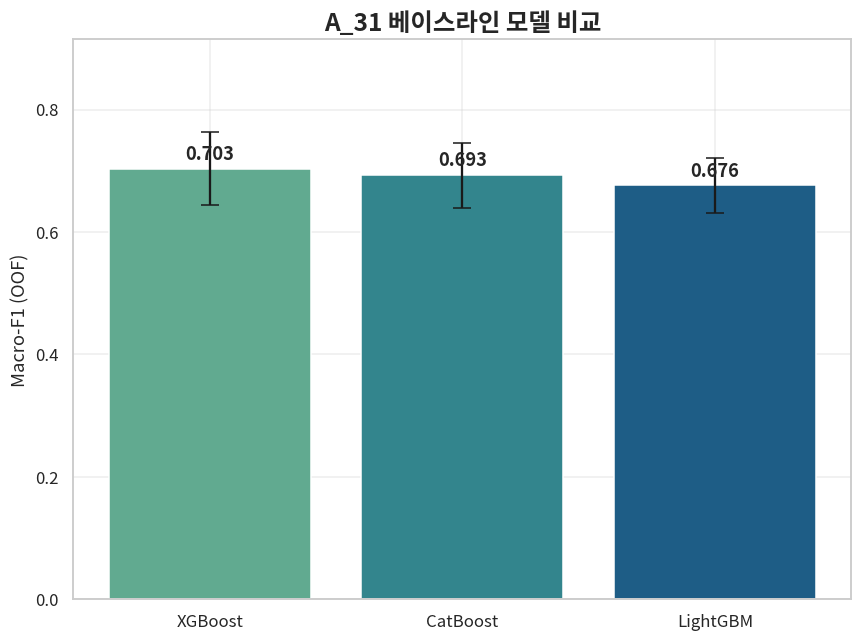

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
order = summary_A.index.tolist()
bars = ax.bar(order, summary_A.loc[order, 'oof_f1'], color=PAL3,
              yerr=summary_A.loc[order, 'fold_std'], capsize=6)
for b, v in zip(bars, summary_A.loc[order, 'oof_f1']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(summary_A['oof_f1']) * 1.3)
ax.set_ylabel('Macro-F1 (OOF)')
ax.set_title('A_31 베이스라인 모델 비교')
plt.tight_layout()
plt.show()


In [9]:
note = "316개 표본에 피처가 훨씬 많은 p≫n 구조라 폴드 변동이 크고, 이 단계에서 특정 모델의 우위를 단정하기는 이르다."
insight_baseline("A_31", summary_A, results_A, note)

**해석 (자동 생성).** A_31 베이스라인 OOF Macro-F1은 XGBoost(0.703) > CatBoost(0.693) > LightGBM(0.676) 순이다. 최상위·최하위 차이(0.027)도 폴드 표준편차(약 0.05~0.06) 범위 안이라 뚜렷한 우열로 보기 어렵고, 세 모델을 사실상 비슷한 수준으로 본다. 표본이 적어 폴드별 F1이 0.60~0.78까지 변동한다. 316개 표본에 피처가 훨씬 많은 p≫n 구조라 폴드 변동이 크고, 이 단계에서 특정 모델의 우위를 단정하기는 이르다.

## 5. TO_31 베이스라인 비교

In [10]:
results_TO = {}
for name, builder in MODEL_BUILDERS.items():
    results_TO[name] = run_cv_regression(builder, X_TO, yq_TO, yc_TO, weight_map_TO, folds_TO)
    r = results_TO[name]
    print(f"[TO_31] {name:9s}  OOF Macro-F1 = {r['oof_f1']:.3f}  (폴드별 {np.round(r['fold_f1'], 3).tolist()})")


[TO_31] CatBoost   OOF Macro-F1 = 0.651  (폴드별 [0.66, 0.554, 0.677, 0.622, 0.719])


[TO_31] XGBoost    OOF Macro-F1 = 0.643  (폴드별 [0.574, 0.503, 0.668, 0.745, 0.684])


[TO_31] LightGBM   OOF Macro-F1 = 0.635  (폴드별 [0.595, 0.564, 0.607, 0.744, 0.649])


In [11]:
summary_TO = pd.DataFrame({
    name: {'oof_f1': r['oof_f1'], 'fold_mean': r['fold_f1'].mean(), 'fold_std': r['fold_f1'].std()}
    for name, r in results_TO.items()
}).T.sort_values('oof_f1', ascending=False)
summary_TO


,oof_f1,fold_mean,fold_std
CatBoost,0.650659,0.646426,0.055614
XGBoost,0.642857,0.634912,0.085534
LightGBM,0.634611,0.631881,0.062429


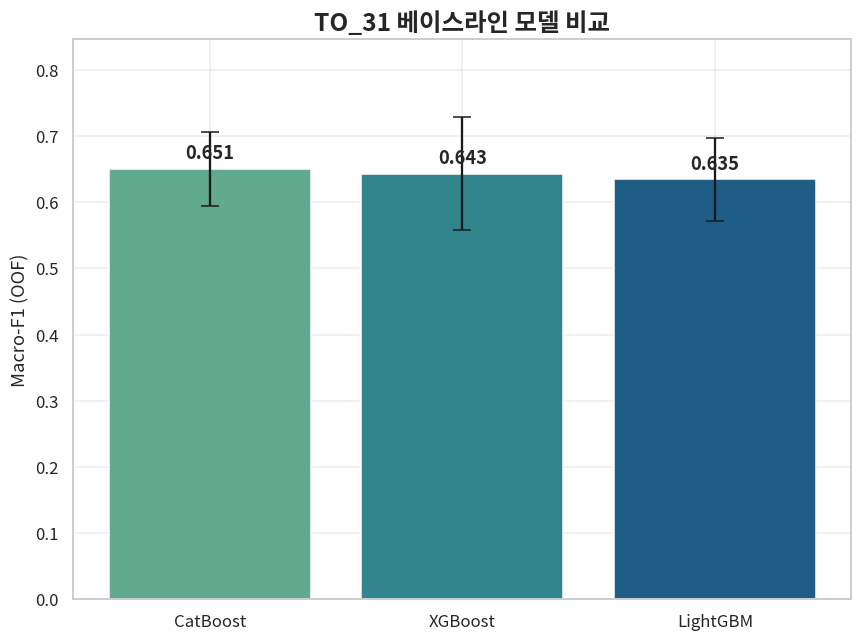

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
order = summary_TO.index.tolist()
bars = ax.bar(order, summary_TO.loc[order, 'oof_f1'], color=PAL3,
              yerr=summary_TO.loc[order, 'fold_std'], capsize=6)
for b, v in zip(bars, summary_TO.loc[order, 'oof_f1']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(summary_TO['oof_f1']) * 1.3)
ax.set_ylabel('Macro-F1 (OOF)')
ax.set_title('TO_31 베이스라인 모델 비교')
plt.tight_layout()
plt.show()


In [13]:
note = "1등급이 약 83%인 심한 불균형이라 소수 등급(0·2등급) 예측이 흔들리는 것이 낮은 성능의 주된 원인이다."
insight_baseline("TO_31", summary_TO, results_TO, note)

**해석 (자동 생성).** TO_31 베이스라인 OOF Macro-F1은 CatBoost(0.651) > XGBoost(0.643) > LightGBM(0.635) 순이다. 최상위·최하위 차이(0.016)도 폴드 표준편차(약 0.06~0.09) 범위 안이라 뚜렷한 우열로 보기 어렵고, 세 모델을 사실상 비슷한 수준으로 본다. 표본이 적어 폴드별 F1이 0.50~0.74까지 변동한다. 1등급이 약 83%인 심한 불균형이라 소수 등급(0·2등급) 예측이 흔들리는 것이 낮은 성능의 주된 원인이다.

## 6. 앙상블(2모델 / 3모델) 비교

세 모델은 같은 폴드 구성을 썼으므로, 같은 검증 표본에 대한 OOF `Y_Quality` 예측을 서로 평균 내는 것만으로 앙상블을 만들 수 있다(추가 학습이 필요 없는 블렌딩 방식이며, 폴드 구성이 같으므로 누수가 생기지 않는다). 2모델 조합은 각 제품에서 베이스라인 Macro-F1이 가장 높은 두 모델을, 3모델 조합은 세 모델 전부를 단순 평균한다.

In [14]:
def blend_and_score(results, model_names, y_class):
    preds = np.mean([results[m]['oof_pred_quality'] for m in model_names], axis=0)
    pred_class = quality_to_class(preds)
    f1 = f1_score(y_class, pred_class, average='macro', labels=[0, 1, 2], zero_division=0)
    return f1, preds


def build_ensemble_table(results, summary, y_class):
    rows = {}
    for name in summary.index:
        rows[name] = summary.loc[name, 'oof_f1']

    top2 = summary.sort_values('oof_f1', ascending=False).index[:2].tolist()
    all3 = summary.index.tolist()

    f1_2, _ = blend_and_score(results, top2, y_class)
    f1_3, _ = blend_and_score(results, all3, y_class)

    rows[f"2모델 앙상블 ({' + '.join(top2)})"] = f1_2
    rows[f"3모델 앙상블 (전체)"] = f1_3

    table = pd.Series(rows, name='oof_f1').sort_values(ascending=False).to_frame()
    return table


table_A = build_ensemble_table(results_A, summary_A, yc_A)
table_TO = build_ensemble_table(results_TO, summary_TO, yc_TO)

print('=== A_31 ===')
print(table_A)
print()
print('=== TO_31 ===')
print(table_TO)


=== A_31 ===
                                oof_f1
2모델 앙상블 (XGBoost + CatBoost)  0.703694
XGBoost                       0.703348
3모델 앙상블 (전체)                  0.695370
CatBoost                      0.692716
LightGBM                      0.675930

=== TO_31 ===
                                oof_f1
2모델 앙상블 (CatBoost + XGBoost)  0.668903
3모델 앙상블 (전체)                  0.666500
CatBoost                      0.650659
XGBoost                       0.642857
LightGBM                      0.634611


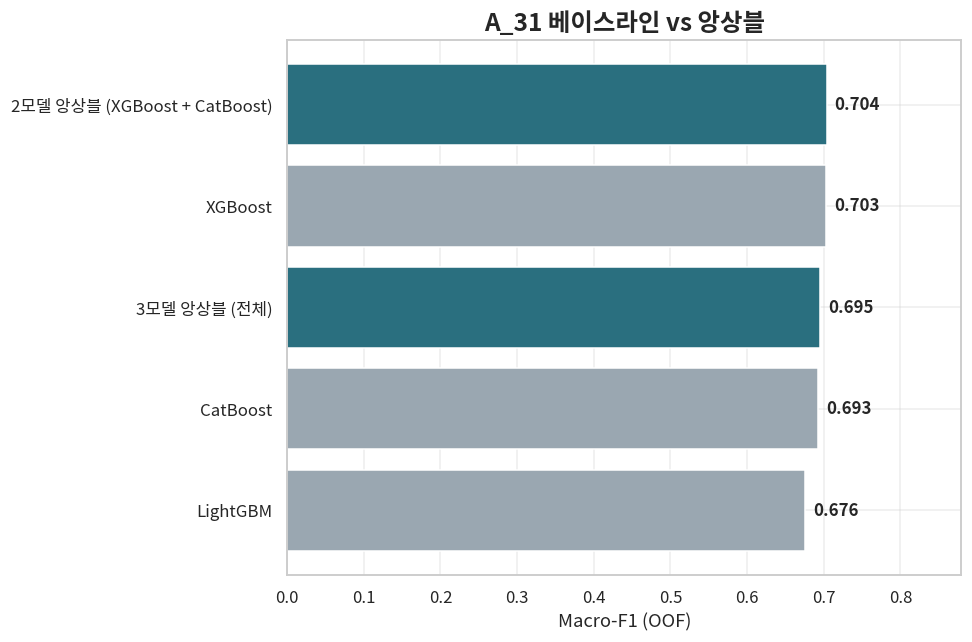

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [ACCENT if '앙상블' in i else GREY for i in table_A.index]
bars = ax.barh(table_A.index[::-1], table_A['oof_f1'][::-1], color=colors[::-1])
for b, v in zip(bars, table_A['oof_f1'][::-1]):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}", va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, table_A['oof_f1'].max() * 1.25)
ax.set_xlabel('Macro-F1 (OOF)')
ax.set_title('A_31 베이스라인 vs 앙상블')
plt.tight_layout()
plt.show()


In [16]:
note = "세 모델 예측이 비슷할수록(다양성이 낮을수록) 단순 평균 이득은 작아지며, 앙상블에는 성능이 검증된 모델만 넣는 것이 안전하다."
insight_ensemble("A_31", table_A, summary_A, note)

**해석 (자동 생성).** A_31 순위: 2모델 앙상블(0.704) > XGBoost(0.703) > 3모델 앙상블(0.695) > CatBoost(0.693) > LightGBM(0.676). 최고 앙상블(0.704)과 최고 단일 모델(XGBoost 0.703)이 사실상 같아 앙상블의 추가 이득은 미미하다. 세 모델 예측이 비슷할수록(다양성이 낮을수록) 단순 평균 이득은 작아지며, 앙상블에는 성능이 검증된 모델만 넣는 것이 안전하다.

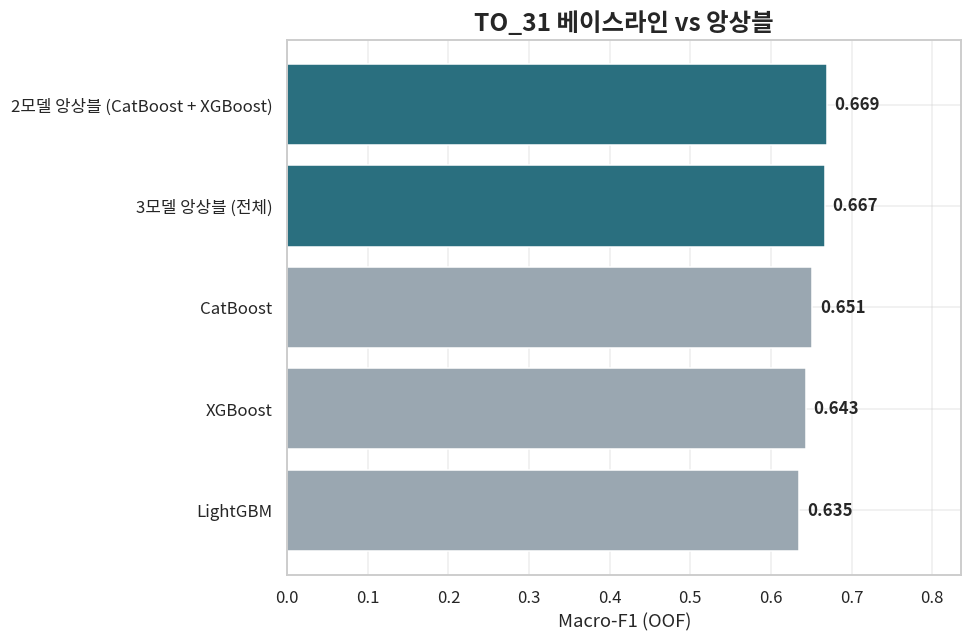

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [ACCENT if '앙상블' in i else GREY for i in table_TO.index]
bars = ax.barh(table_TO.index[::-1], table_TO['oof_f1'][::-1], color=colors[::-1])
for b, v in zip(bars, table_TO['oof_f1'][::-1]):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}", va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, table_TO['oof_f1'].max() * 1.25)
ax.set_xlabel('Macro-F1 (OOF)')
ax.set_title('TO_31 베이스라인 vs 앙상블')
plt.tight_layout()
plt.show()


In [18]:
note = "불균형이 심한 제품에서는 다음 단계로 소수 등급 특화 기법(등급별 임계값 재조정, 성능 비례 가중 평균)을 검토할 수 있다."
insight_ensemble("TO_31", table_TO, summary_TO, note)

**해석 (자동 생성).** TO_31 순위: 2모델 앙상블(0.669) > 3모델 앙상블(0.667) > CatBoost(0.651) > XGBoost(0.643) > LightGBM(0.635). 최고 앙상블(2모델 앙상블 0.669)이 최고 단일 모델(CatBoost 0.651)보다 +0.018 높아 앙상블이 도움이 된다. 불균형이 심한 제품에서는 다음 단계로 소수 등급 특화 기법(등급별 임계값 재조정, 성능 비례 가중 평균)을 검토할 수 있다.

## 7. 종합 정리 및 한계

아래 **종합 요약**은 실제 실행 결과에서 자동 생성되므로 차트·표와 항상 일치한다.

In [19]:
# 종합 요약 자동 생성 (제품별 최고 단일 vs 최고 앙상블)
def consolidated_summary():
    md = "### 종합 요약 (자동 생성)\n\n| 제품 | 최고 단일 | 최고 앙상블 | 앙상블 이득 |\n|---|---|---|---|\n"
    for product, summary, table in [("A_31", summary_A, table_A), ("TO_31", summary_TO, table_TO)]:
        bs = summary.sort_values("oof_f1", ascending=False).index[0]
        bsv = summary.loc[bs, "oof_f1"]
        t = table.sort_values("oof_f1", ascending=False)
        ens_rows = [i for i in t.index if "앙상블" in i]
        eb = max(ens_rows, key=lambda r: t.loc[r, "oof_f1"])
        ebv = t.loc[eb, "oof_f1"]
        d = ebv - bsv
        verdict = "있음" if d > 0.003 else ("없음" if d < -0.003 else "미미")
        md += f"| {product} | {bs} {bsv:.3f} | {eb.split('(')[0].strip()} {ebv:.3f} | {verdict} ({d:+.3f}) |\n"
    return Markdown(md)

consolidated_summary()

### 종합 요약 (자동 생성)

| 제품 | 최고 단일 | 최고 앙상블 | 앙상블 이득 |
|---|---|---|---|
| A_31 | XGBoost 0.703 | 2모델 앙상블 0.704 | 미미 (+0.000) |
| TO_31 | CatBoost 0.651 | 2모델 앙상블 0.669 | 있음 (+0.018) |


**한계.**
- 하이퍼파라미터를 모델당 하나로 고정한 '베이스라인' 비교라, 각 모델의 최선 성능은 아니다.
- 앙상블은 동일 가중 단순 평균이라, 성능이 낮은 모델이 섞이면 오히려 손해를 볼 수 있다.
- A_31은 표본이 316개뿐이라 5-Fold 각 폴드 검증 표본이 60여 개에 불과해 폴드 간 성능 변동이 넓다.
- 최종 F1 수치는 CatBoost·XGBoost·LightGBM의 라이브러리 버전·스레드 수에 따라 조금씩 달라질 수 있다(시드는 고정). 그래서 위 해석·요약은 모두 실제 실행값에서 자동 생성해 차트와 어긋나지 않게 했다.
- 0.525 / 0.535 경계값은 제품 전체에 적용한 근사 규칙으로 실제 등급과 완전히 일치하지는 않는다.

**개선 방향(제안).**
1. Optuna 등으로 모델별 하이퍼파라미터를 탐색해 성능 상한을 확인한다.
2. 단순 평균 대신 성능 비례 가중 평균, 또는 스태킹으로 앙상블을 고도화한다.
3. 반복 교차검증(repeated stratified k-fold)으로 폴드 변동을 줄이고 신뢰구간을 함께 보고한다.
4. 제품코드별 경계값을 각각 추정해 규칙과 실제 등급의 불일치를 줄인다.

이 중 어떤 방향을 다음 단계로 진행할지 알려주면 그 부분부터 이어서 작업한다.